In [5]:
import pandas as pd

# Load the Titanic dataset
df = pd.read_csv('tested.csv')

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Identify missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)

# Separate numeric and non-numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns

# Fill missing values for numeric columns with the mean
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Optionally fill missing values for non-numeric columns
# For example, fill missing values with the mode for non-numeric columns
df[non_numeric_cols] = df[non_numeric_cols].fillna(df[non_numeric_cols].mode().iloc[0])

# Check the DataFrame after filling missing values
print("\nDataset after filling missing values:")
print(df.head())
print("\nMissing values after filling:")
print(df.isnull().sum())


First few rows of the dataset:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Missing values in each column:
PassengerId      0
Surv

In [10]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the Titanic dataset
df = pd.read_csv('tested.csv')

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Select numeric columns only
numeric_cols = df.select_dtypes(include=['number']).columns

# Drop rows with missing values for Z-score calculation
df_numeric = df[numeric_cols].dropna()

# Calculate Z-scores for the numeric columns
z_scores = np.abs(stats.zscore(df_numeric))

# Identify outliers (Z-score > 3)
outliers = (z_scores > 3)
outlier_indices = df_numeric[outliers.any(axis=1)].index

# Print the outliers
print("\nOutliers in the dataset:")
print(df.loc[outlier_indices])

# Option 1: Remove the outliers
df_no_outliers = df.drop(index=outlier_indices)

# Option 2: Replace outliers with a threshold value
df_threshold = df.copy()
for col in numeric_cols:
    threshold = 3
    mean = df_threshold[col].mean()
    std = df_threshold[col].std()
    upper_limit = mean + threshold * std
    lower_limit = mean - threshold * std
    df_threshold.loc[df_threshold[col] > upper_limit, col] = upper_limit
    df_threshold.loc[df_threshold[col] < lower_limit, col] = lower_limit

# Display the datasets after handling outliers
print("\nDataset after removing outliers:")
print(df_no_outliers.head())

print("\nDataset after replacing outliers with threshold values:")
print(df_threshold.head())


First few rows of the dataset:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Outliers in the dataset:
     PassengerId  Survived  P

In [11]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load the Iris dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(url, header=None, names=columns)

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Select numeric columns only
numeric_cols = df.select_dtypes(include=['number']).columns

# Min-Max Normalization
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])

# Z-score Normalization
scaler_zscore = StandardScaler()
df_zscore = df.copy()
df_zscore[numeric_cols] = scaler_zscore.fit_transform(df[numeric_cols])

# Display the normalized datasets
print("\nDataset after Min-Max Normalization:")
print(df_minmax.head())

print("\nDataset after Z-score Normalization:")
print(df_zscore.head())

First few rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset after Min-Max Normalization:
   sepal_length  sepal_width  petal_length  petal_width        class
0      0.222222     0.625000      0.067797     0.041667  Iris-setosa
1      0.166667     0.416667      0.067797     0.041667  Iris-setosa
2      0.111111     0.500000      0.050847     0.041667  Iris-setosa
3      0.083333     0.458333      0.084746     0.041667  Iris-setosa
4      0.194444     0.666667      0.067797     0.041667  Iris-setosa

Dataset after Z-score Normalization:
   sepal_length  sepal_width  petal_length  petal_width        cl

First few rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


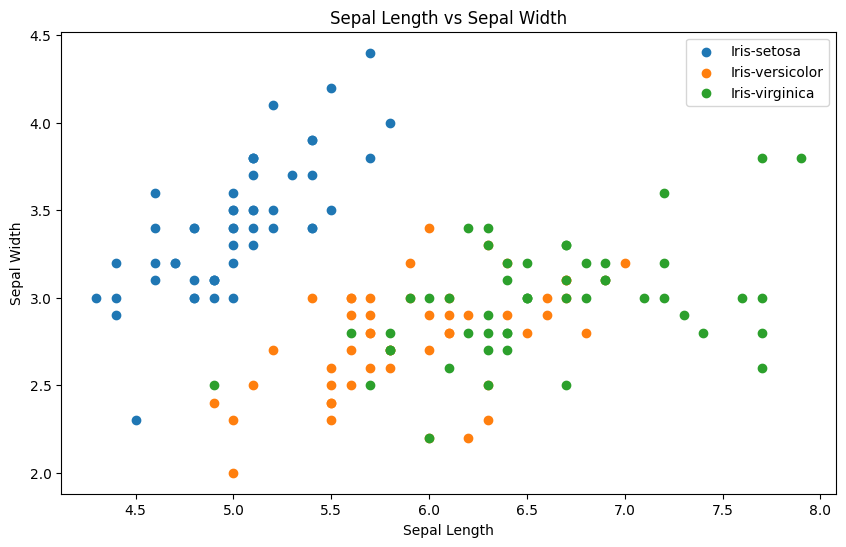

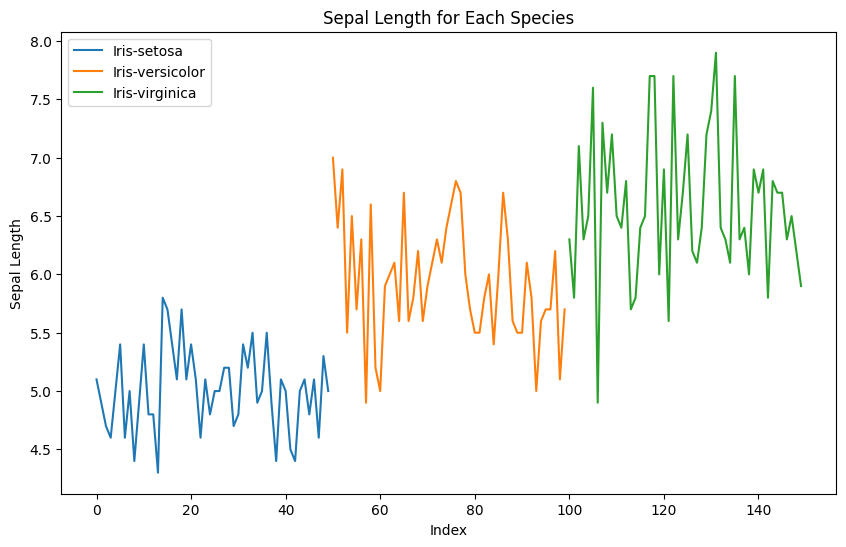

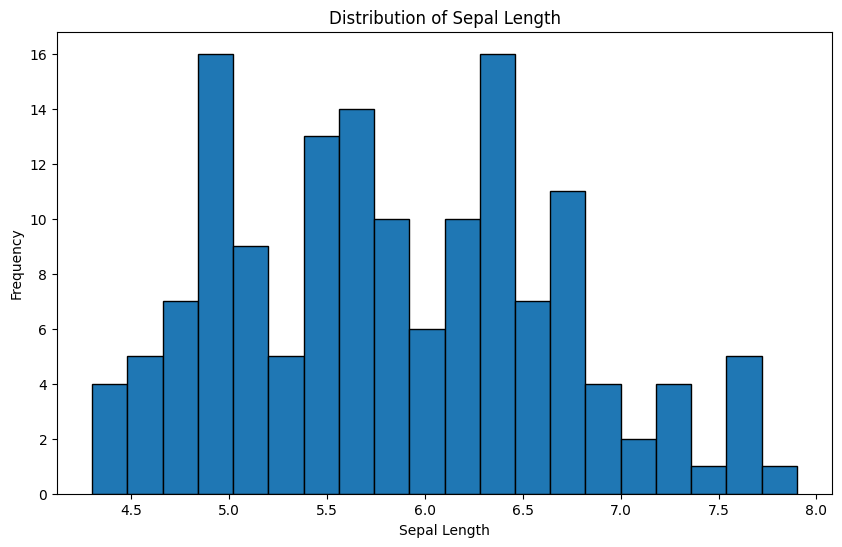

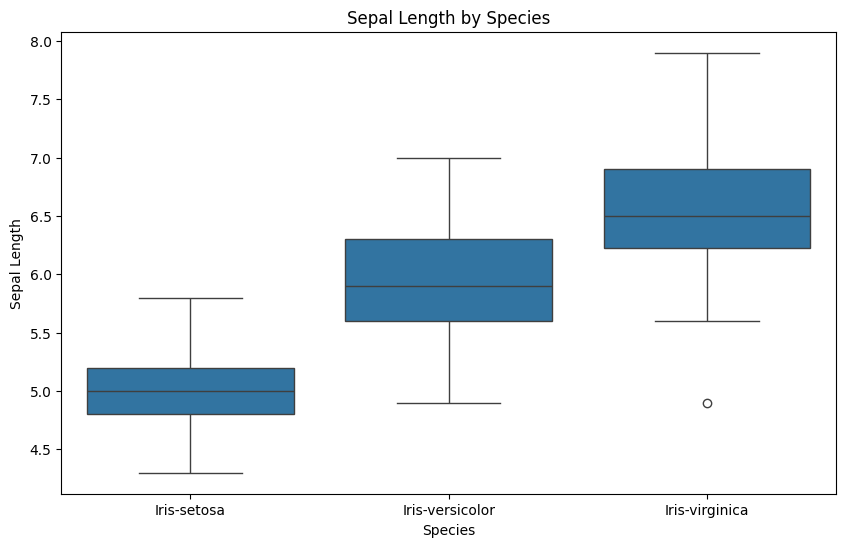

<Figure size 1000x600 with 0 Axes>

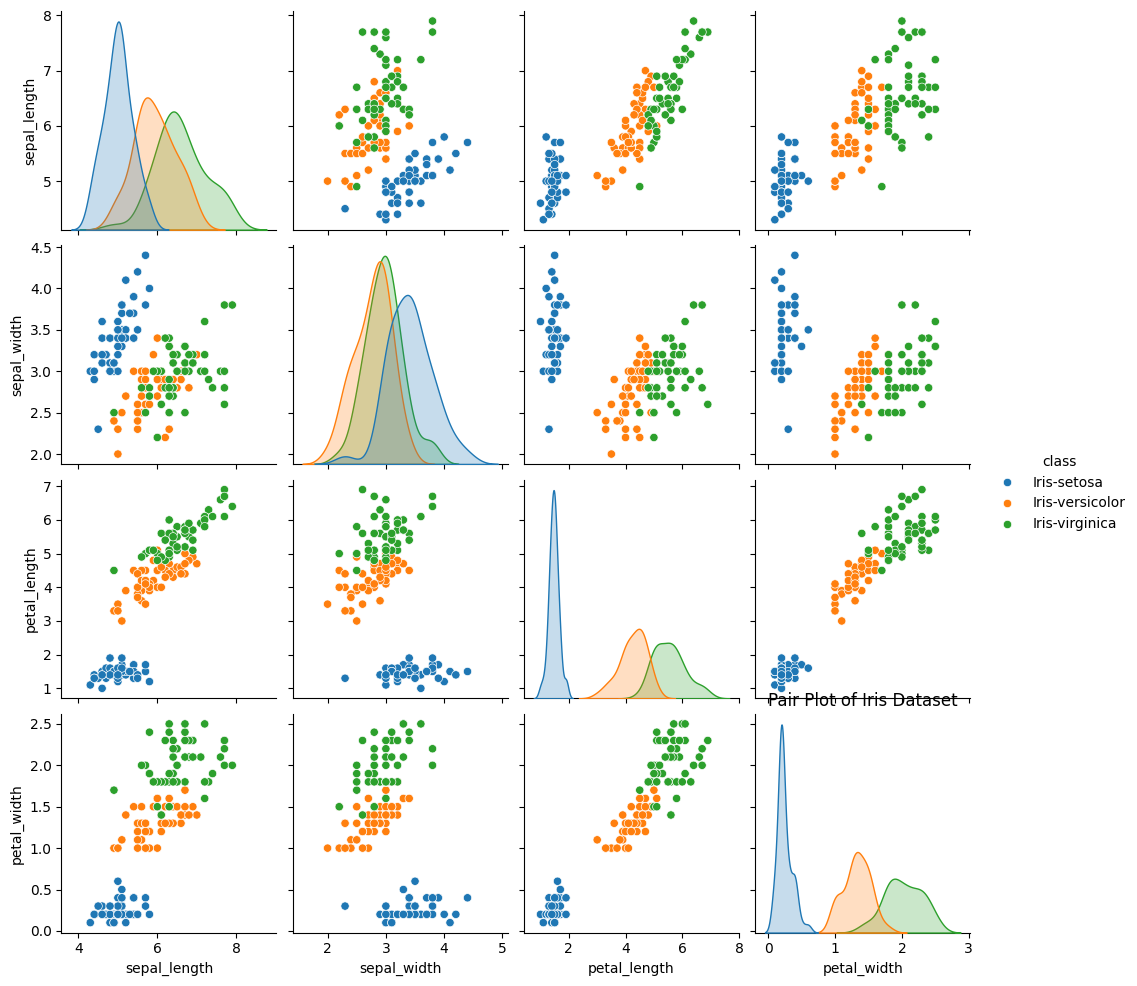

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(url, header=None, names=columns)

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Scatter plot: Sepal Length vs Sepal Width
plt.figure(figsize=(10, 6))
for species in df['class'].unique():
    subset = df[df['class'] == species]
    plt.scatter(subset['sepal_length'], subset['sepal_width'], label=species)
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.show()

# Line plot: Sepal Length for each species
plt.figure(figsize=(10, 6))
for species in df['class'].unique():
    subset = df[df['class'] == species]
    plt.plot(subset['sepal_length'], label=species)
plt.title('Sepal Length for Each Species')
plt.xlabel('Index')
plt.ylabel('Sepal Length')
plt.legend()
plt.show()

# Histogram: Distribution of Sepal Length
plt.figure(figsize=(10, 6))
plt.hist(df['sepal_length'], bins=20, edgecolor='black')
plt.title('Distribution of Sepal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

# Box plot: Sepal Length by Species
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='sepal_length', data=df)
plt.title('Sepal Length by Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length')
plt.show()

# Pair plot: Relationship between all numeric features
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue='class')
plt.title('Pair Plot of Iris Dataset')
plt.show()
